# Data analysis for Insurance company: Health Insurance Cross Sell Prediction

Data: ('train.csv') https://www.kaggle.com/datasets/anmolkumar/health-insurance-cross-sell-prediction

In [ ]:
# ============================================
# CELL 1 — Import libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# ============================================
# CELL 2 — Read dataset
# ============================================

df = pd.read_csv("train.csv")

df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [ ]:
# Delete the 'Driving_License' column
df = df.drop('Driving_License', axis=1)

# Display the first 5 rows of the updated DataFrame
df.head()

,id,Gender,Age,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [ ]:
display(df.head(15))

,id,Gender,Age,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,41.0,1,< 1 Year,No,27496.0,152.0,39,0
5,6,Female,24,33.0,0,< 1 Year,Yes,2630.0,160.0,176,0
6,7,Male,23,11.0,0,< 1 Year,Yes,23367.0,152.0,249,0
7,8,Female,56,28.0,0,1-2 Year,Yes,32031.0,26.0,72,1
8,9,Female,24,3.0,1,< 1 Year,No,27619.0,152.0,28,0
9,10,Female,32,6.0,1,< 1 Year,No,28771.0,152.0,80,0


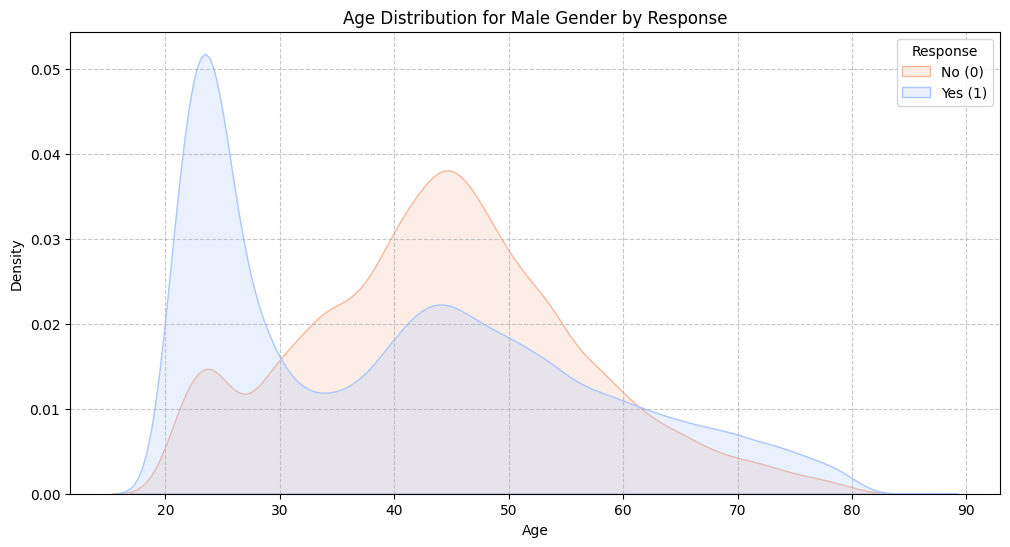

In [ ]:
# Create KDE plots for male ages, split by Response
males_df = df[df['Gender'] == 'Male']
plt.figure(figsize=(12, 6))
sns.kdeplot(data=males_df, x='Age', hue='Response', fill=True, common_norm=False, palette='coolwarm')
plt.title('Age Distribution for Male Gender by Response')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Response', labels=['No (0)', 'Yes (1)'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Create 'Age_Group' column

bins = [0, 18, 25, 35, 45, 55, 65, np.inf]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

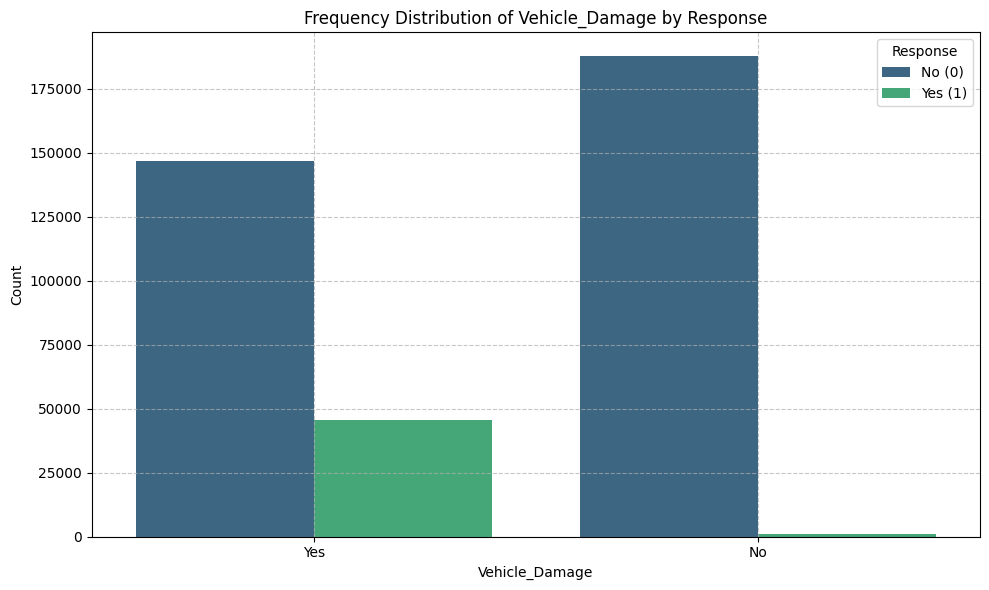

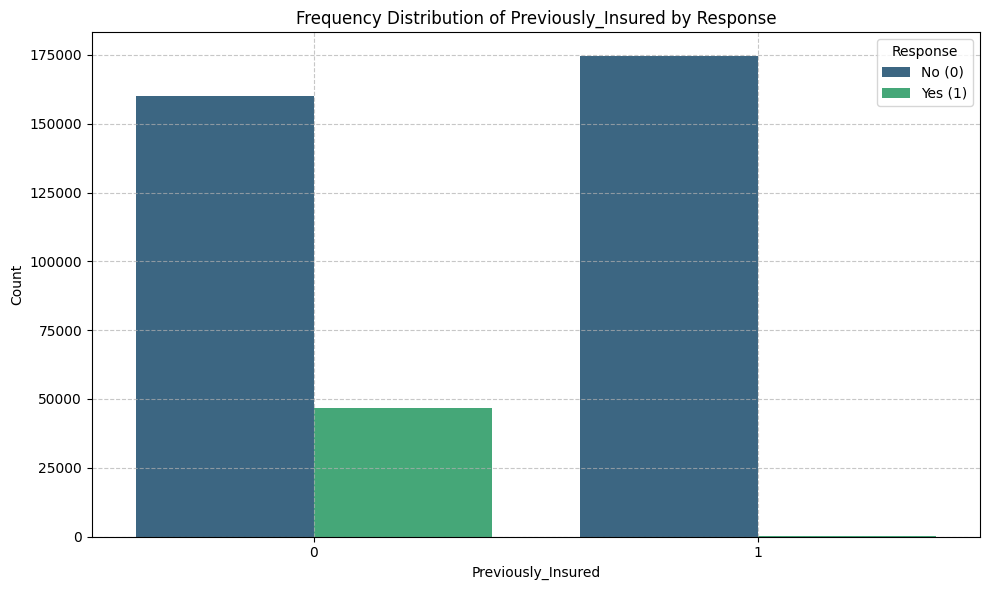

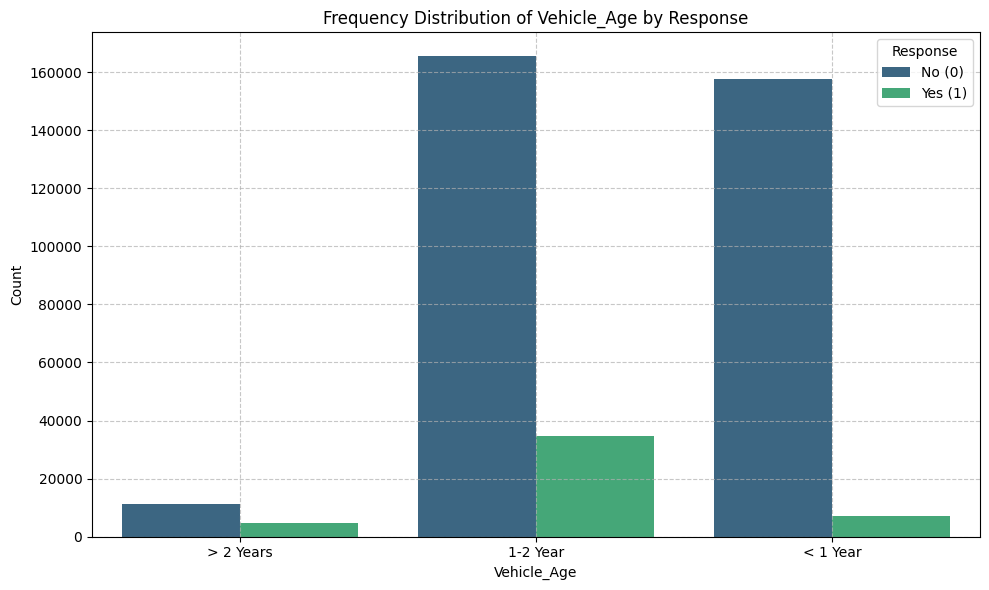

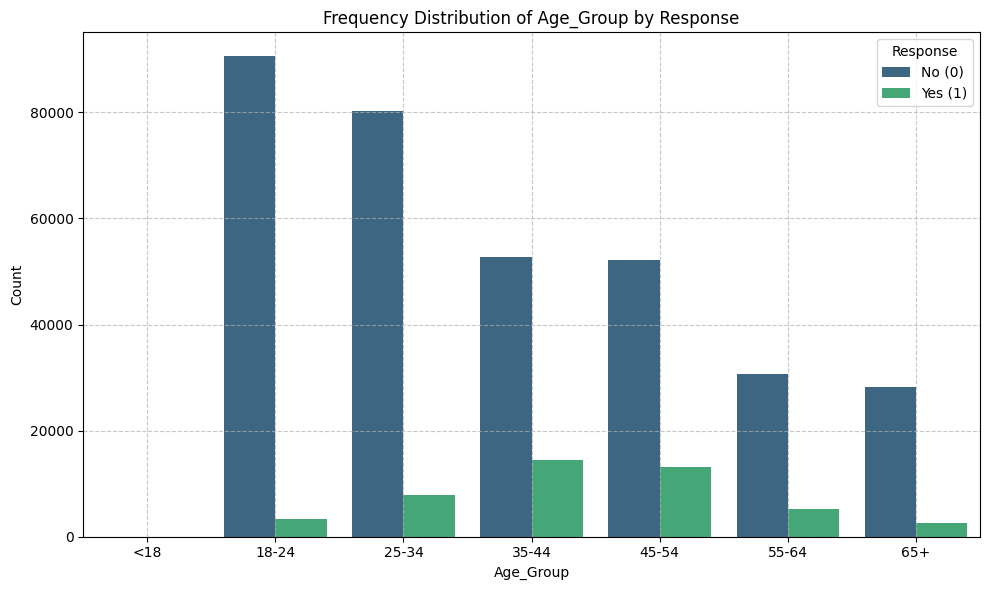

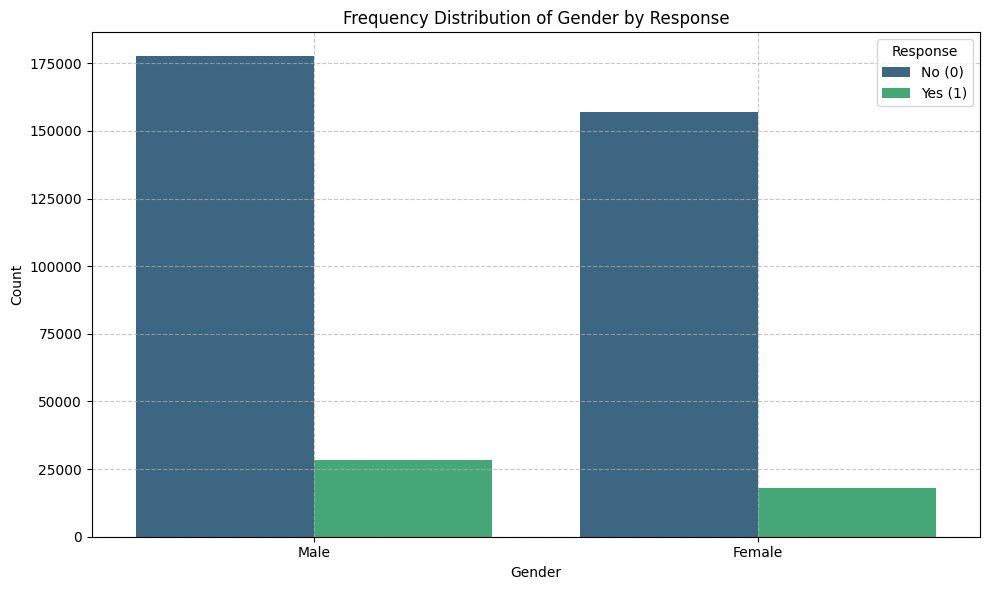

In [ ]:
# List of categorical columns to plot against 'Response'
categorical_cols = ['Vehicle_Damage', 'Previously_Insured', 'Vehicle_Age', 'Age_Group', 'Gender']

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue='Response', palette='viridis')
    plt.title(f'Frequency Distribution of {col} by Response')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Response', labels=['No (0)', 'Yes (1)'])
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Based on the above we can conclude that If a person meets the below conditions they are more likely be interested to be insured:

1. Age groups
    1. 35-54 - most liekly
2. Car 1-2 years old (VEHICLE_AGE = 1-2)
3. Previusly not insured
4. Had vehicle damage = 1



In [ ]:
pd.crosstab(df["Vehicle_Damage"], df["Response"], normalize="index")

Response,0,1
Vehicle_Damage,,
No,0.994796,0.005204
Yes,0.762345,0.237655


In [ ]:
pd.crosstab(df["Previously_Insured"], df["Response"], normalize="index")

Response,0,1
Previously_Insured,,
0,0.774546,0.225454
1,0.999095,0.000905


In [ ]:
pd.crosstab(df["Vehicle_Age"], df["Response"], normalize="index")

Response,0,1
Vehicle_Age,,
1-2 Year,0.826245,0.173755
< 1 Year,0.956295,0.043705
> 2 Years,0.706254,0.293746


In [ ]:
pd.crosstab(df["Age_Group"], df["Response"], normalize="index")

Response,0,1
Age_Group,,
18-24,0.964706,0.035294
25-34,0.911143,0.088857
35-44,0.784068,0.215932
45-54,0.798243,0.201757
55-64,0.854230,0.145770
65+,0.913804,0.086196


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   id                    381109 non-null  int64   
 1   Gender                381109 non-null  object  
 2   Age                   381109 non-null  int64   
 3   Region_Code           381109 non-null  float64 
 4   Previously_Insured    381109 non-null  int64   
 5   Vehicle_Age           381109 non-null  object  
 6   Vehicle_Damage        381109 non-null  object  
 7   Annual_Premium        381109 non-null  float64 
 8   Policy_Sales_Channel  381109 non-null  float64 
 9   Vintage               381109 non-null  int64   
 10  Response              381109 non-null  int64   
 11  Age_Group             381109 non-null  category
 12  Risk_Profile          381109 non-null  object  
dtypes: category(1), float64(3), int64(5), object(4)
memory usage: 35.3+ MB


## Calcualte Risk profile

In [ ]:
def calculate_risk_profile(row):
    score = 0

    if row["Vehicle_Damage"] == "Yes":
        score += 2

    if row["Vehicle_Age"] == "> 2 Years":
        score += 2
    elif row["Vehicle_Age"] == "1-2 Year":
        score += 1

    if row["Previously_Insured"] == 0:
        score += 1

    if score >= 4:
        return "High"
    elif score >= 2:
        return "Medium"
    else:
        return "Low"

df["Risk_Profile"] = df.apply(calculate_risk_profile, axis=1)

In [ ]:
pd.crosstab(df["Risk_Profile"], df["Response"], normalize="index")

Response,0,1
Risk_Profile,,
High,0.719086,0.280914
Low,0.997585,0.002415
Medium,0.888739,0.111261


In [ ]:
display(df.head(15))

,id,Gender,Age,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Age_Group,Risk_Profile
0,1,Male,44,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1,35-44,High
1,2,Male,76,3.0,0,1-2 Year,No,33536.0,26.0,183,0,65+,Medium
2,3,Male,47,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1,45-54,High
3,4,Male,21,11.0,1,< 1 Year,No,28619.0,152.0,203,0,18-24,Low
4,5,Female,29,41.0,1,< 1 Year,No,27496.0,152.0,39,0,25-34,Low
5,6,Female,24,33.0,0,< 1 Year,Yes,2630.0,160.0,176,0,18-24,Medium
6,7,Male,23,11.0,0,< 1 Year,Yes,23367.0,152.0,249,0,18-24,Medium
7,8,Female,56,28.0,0,1-2 Year,Yes,32031.0,26.0,72,1,55-64,High
8,9,Female,24,3.0,1,< 1 Year,No,27619.0,152.0,28,0,18-24,Low
9,10,Female,32,6.0,1,< 1 Year,No,28771.0,152.0,80,0,25-34,Low


#VPI

In [ ]:
df["Vehicle_Damage"].value_counts(normalize=True)

,proportion
Vehicle_Damage,
Yes,0.504877
No,0.495123


In [ ]:
df["Previously_Insured"].value_counts(normalize=True)

,proportion
Previously_Insured,
0,0.54179
1,0.45821


In [ ]:
df["Vehicle_Age"].value_counts(normalize=True)

,proportion
Vehicle_Age,
1-2 Year,0.525613
< 1 Year,0.432385
> 2 Years,0.042001


In [ ]:
df["Age_Group"].value_counts(normalize=True)

,proportion
Age_Group,
18-24,0.246305
25-34,0.230923
35-44,0.176551
45-54,0.171177
55-64,0.094070
65+,0.080974
<18,0.000000


In [ ]:
df["Response"].value_counts(normalize=True)

,proportion
Response,
0,0.877437
1,0.122563


In [ ]:
pd.crosstab(
    df["Vehicle_Age"],
    df["Vehicle_Damage"],
    normalize="index"
)

NameError: name 'pd' is not defined

# 4.1 Prior (Marginal) Probability Distributions

In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217.0,1.0
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183.0,0.0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27.0,1.0
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203.0,0.0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39.0,0.0


In [ ]:
prior_table = pd.DataFrame({
    "Variable": [
        "Previously_Insured",
        "Previously_Insured",
        "Vehicle_Damage",
        "Vehicle_Damage",
        "Vehicle_Age",
        "Vehicle_Age",
        "Vehicle_Age",
        "Response",
        "Response"
    ],
    "State": [
        "No (not insured)",
        "Yes (already insured)",
        "No",
        "Yes",
        "< 1 Year",
        "1-2 Year",
        "> 2 Years",
        "No (not interested)",
        "Yes (interested)"
    ],
    "P(State)": [
        df["Previously_Insured"].value_counts(normalize=True).loc[0],
        df["Previously_Insured"].value_counts(normalize=True).loc[1],
        df["Vehicle_Damage"].value_counts(normalize=True).loc["No"],
        df["Vehicle_Damage"].value_counts(normalize=True).loc["Yes"],
        df["Vehicle_Age"].value_counts(normalize=True).loc["< 1 Year"],
        df["Vehicle_Age"].value_counts(normalize=True).loc["1-2 Year"],
        df["Vehicle_Age"].value_counts(normalize=True).loc["> 2 Years"],
        df["Response"].value_counts(normalize=True).loc[0],
        df["Response"].value_counts(normal[ ]
# ============================================
# CELL 1 — Import libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns





[ ]
Double-click (or enter) to edit


[ ]
# Delete the 'Driving_License' column
df = df.drop('Driving_License', axis=1)

# Display the first 5 rows of the updated DataFrame
df.head()


[ ]
display(df.head(15))


[ ]

Start coding or generate with AI.

[ ]

Start coding or generate with AI.

[ ]
# Create KDE plots for male ages, split by Response
males_df = df[df['Gender'] == 'Male']
plt.figure(figsize=(12, 6))
sns.kdeplot(data=males_df, x='Age', hue='Response', fill=True, common_norm=False, palette='coolwarm')
plt.title('Age Distribution for Male Gender by Response')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Response', labels=['No (0)', 'Yes (1)'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


[ ]
# Create 'Age_Group' column

bins = [0, 18, 25, 35, 45, 55, 65, np.inf]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

[ ]
# List of categorical columns to plot against 'Response'
categorical_cols = ['Vehicle_Damage', 'Previously_Insured', 'Vehicle_Age', 'Age_Group', 'Gender']

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue='Response', palette='viridis')
    plt.title(f'Frequency Distribution of {col} by Response')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Response', labels=['No (0)', 'Yes (1)'])
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Based on the above we can conclude that If a person meets the below conditions they are more likely be interested to be insured:

Age groups
35-54 - most liekly
Car 1-2 years old (VEHICLE_AGE = 1-2)
Previusly not insured
Had vehicle damage = 1

[ ]
pd.crosstab(df["Vehicle_Damage"], df["Response"], normalize="index")


[ ]
pd.crosstab(df["Previously_Insured"], df["Response"], normalize="index")


[ ]
pd.crosstab(df["Vehicle_Age"], df["Response"], normalize="index")


[ ]
pd.crosstab(df["Age_Group"], df["Response"], normalize="index")


[ ]
df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   id                    381109 non-null  int64
 1   Gender                381109 non-null  object
 2   Age                   381109 non-null  int64
 3   Region_Code           381109 non-null  float64
 4   Previously_Insured    381109 non-null  int64
 5   Vehicle_Age           381109 non-null  object
 6   Vehicle_Damage        381109 non-null  object
 7   Annual_Premium        381109 non-null  float64
 8   Policy_Sales_Channel  381109 non-null  float64
 9   Vintage               381109 non-null  int64
 10  Response              381109 non-null  int64
 11  Age_Group             381109 non-null  category
 12  Risk_Profile          381109 non-null  object
dtypes: category(1), float64(3), int64(5), object(4)
memory usage: 35.3+ MB
Calcualte Risk profile

[ ]
def calculate_risk_profile(row):
    score = 0

    if row["Vehicle_Damage"] == "Yes":
        score += 2

    if row["Vehicle_Age"] == "> 2 Years":
        score += 2
    elif row["Vehicle_Age"] == "1-2 Year":
        score += 1

    if row["Previously_Insured"] == 0:
        score += 1

    if score >= 4:
        return "High"
    elif score >= 2:
        return "Medium"
    else:
        return "Low"

df["Risk_Profile"] = df.apply(calculate_risk_profile, axis=1)

[ ]
pd.crosstab(df["Risk_Profile"], df["Response"], normalize="index")


[ ]
display(df.head(15))

VPI

[ ]
df["Vehicle_Damage"].value_counts(normalize=True)


[ ]
df["Previously_Insured"].value_counts(normalize=True)


[ ]
df["Vehicle_Age"].value_counts(normalize=True)


[ ]
df["Age_Group"].value_counts(normalize=True)


[ ]
df["Response"].value_counts(normalize=True)


[2]
0s
pd.crosstab(
    df["Vehicle_Age"],
    df["Vehicle_Damage"],
    normalize="index"
)


[ ]

Start coding or generate with AI.
4.1 Prior (Marginal) Probability Distributions

[4]
0s
import pandas as pd

df = pd.read_csv("train.csv")
df.head()


[5]
0s
prior_table = pd.DataFrame({
    "Variable": [
        "Previously_Insured",
        "Previously_Insured",
        "Vehicle_Damage",
        "Vehicle_Damage",
        "Vehicle_Age",
        "Vehicle_Age",
        "Vehicle_Age",
        "Response",


Colab paid products - Cancel contracts here
ize=True).loc[1]
    ]
})

prior_table["P(State)"] = prior_table["P(State)"].round(4)

prior_table

,Variable,State,P(State)
0,Previously_Insured,No (not insured),0.5425
1,Previously_Insured,Yes (already insured),0.4575
2,Vehicle_Damage,No,0.4942
3,Vehicle_Damage,Yes,0.5058
4,Vehicle_Age,< 1 Year,0.4345
5,Vehicle_Age,1-2 Year,0.5236
6,Vehicle_Age,> 2 Years,0.0419
7,Response,No (not interested),0.8767
8,Response,Yes (interested),0.1233


In [ ]:

response_probs = (
    df["Response"]
    .value_counts(normalize=True)
    .rename_axis("Response")
    .reset_index(name="P(Response)")
)

response_probs



,Response,P(Response)
0,0.0,0.876664
1,1.0,0.123336


In [ ]:
df["Vehicle_Damage"].value_counts(normalize=True)

pd.crosstab(
    df["Vehicle_Damage"],
    df["Response"],
    normalize="index"
)

Response,0.0,1.0
Vehicle_Damage,,
No,0.995038,0.004962
Yes,0.761008,0.238992


In [1]:
vd_response_table = pd.crosstab(
    df["Vehicle_Damage"],
    df["Response"],
    normalize="index"
)

p_r1_given_vd_no = vd_response_table.loc["No", 1]
p_r1_given_vd_yes = vd_response_table.loc["Yes", 1]

p_vd_no = df["Vehicle_Damage"].value_counts(normalize=True).loc["No"]
p_vd_yes = df["Vehicle_Damage"].value_counts(normalize=True).loc["Yes"]

print("P(R=1 | VD=No):", p_r1_given_vd_no)
print("P(R=1 | VD=Yes):", p_r1_given_vd_yes)

print("P(VD=No):", p_vd_no)
print("P(VD=Yes):", p_vd_yes)

NameError: name 'pd' is not defined